In [32]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, roc_auc_score


In [33]:
df = pd.DataFrame(pd.read_csv("./data/dermatology_database_1.csv"))
tmp = df.loc[df["age"]== "?"].index
df.drop(tmp, inplace=True)
df["age"] = df["age"].astype(np.float32)
df["class"] = df["class"].apply(lambda x: x-1)
df.shape


(358, 35)

In [34]:
df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,1
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,0
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,2
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,0
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,2


In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 42


In [36]:
y = np.array(df["class"])
X = np.array(df.drop(["class"], axis=1))


In [37]:
scaler = RobustScaler()

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=seed
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=seed
)

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

out_dim = len(np.unique(y))
in_dim = X_train.shape[1]


In [38]:
X_train = torch.from_numpy(X_train).float().to(device)
y_train = torch.from_numpy(y_train).long().to(device)

X_val = torch.from_numpy(X_val).float().to(device)
y_val = torch.from_numpy(y_val).long().to(device)

X_test = torch.from_numpy(X_test).float().to(device)
y_test = torch.from_numpy(y_test).long().to(device)

y = torch.from_numpy(y).long().to(device)
X = torch.from_numpy(X).float().to(device)



In [40]:
class NN_multiclassifire(nn.Module):
    def __init__(self, input_dim, hidden_later_dims, output_dim, droputs):
        super().__init__()
        layer_dims= [input_dim] + hidden_later_dims
        n_layers = len(layer_dims)
        layers = []
        
        for i in range(n_layers-1):
            layers.append(nn.Linear(layer_dims[i], layer_dims[i+1]))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(droputs[i]))
        
        layers.append(nn.Linear(layer_dims[-1], output_dim))
        
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

num_epochs = 600
model = NN_multiclassifire(in_dim, [128, 64, 16], out_dim, [0.1, 0.2, 0.3]).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-4)

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    
    logits = model(X_train)
    
    train_loss = criterion(logits, y_train)
    
    train_loss.backward()
    optimizer.step()
    
    model.eval()
    predicted_logits = model(X_val)
    val_loss = criterion(predicted_logits, y_val)
    
    if (epoch+1)%200 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}] | train_Loss: {train_loss.item():.4f} | valid_loss: {val_loss.item():.4f}')

            

Epoch [200/600] | train_Loss: 0.0130 | valid_loss: 0.0268
Epoch [400/600] | train_Loss: 0.0214 | valid_loss: 0.0164
Epoch [600/600] | train_Loss: 0.0128 | valid_loss: 0.0085


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       0.83      0.94      0.88        16
           2       1.00      0.95      0.98        22
           3       0.93      0.88      0.90        16
           4       1.00      1.00      1.00        14
           5       1.00      1.00      1.00         6

    accuracy                           0.96       108
   macro avg       0.96      0.96      0.96       108
weighted avg       0.97      0.96      0.96       108



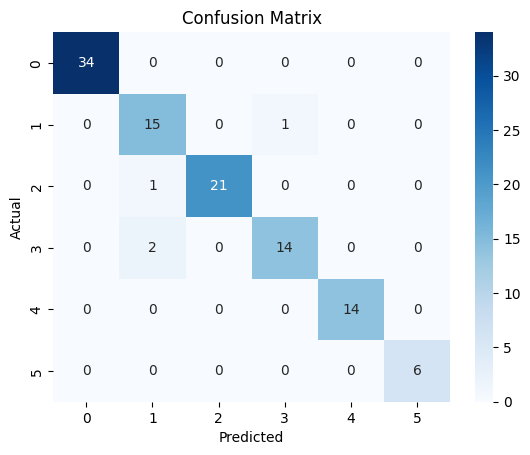

In [43]:
model.eval()
test_logits = model(X_test)
test_probs = nn.functional.softmax(test_logits, dim=1)
test_preds = torch.argmax(test_probs, dim=1)

print(classification_report(test_preds.cpu().numpy(), y_test.cpu().numpy()))

cm = confusion_matrix(test_preds.cpu().numpy(), y_test.cpu().numpy())

plt.Figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues", )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


